#**DATA PREPROCESSING**

**Import the important libraries.**

In [1]:

import pandas as pd
import numpy as np
from scipy import stats
import plotly.express as px
import seaborn as sns
import matplotlib.pyplot as plt
from ipywidgets import interact, widgets


**Load the dataset**

In [2]:
# Load the dataset
car = pd.read_csv("/content/cars_for_sale(cleaned).csv")

FileNotFoundError: [Errno 2] No such file or directory: '/content/cars_for_sale(cleaned).csv'

In [ ]:
#
car.head()

,Make,Year,Condition,Mileage,Price,Seller Rating,Seller Rating Count,Interior color,Drivetrain,Min MPG,...,1-owner vehicle,Personal use only,Clean title,Open recall,Comfort_score,Interior_score,Performance_score,Value_score,Exterior_score,Reliability_score
0,Lexus,2024,New,0.0,112865.0,4.7,1261.0,Black,Rear-wheel Drive,15.0,...,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN
1,Acura,2007,Used,61110.0,11295.0,4.2,440.0,–,Front-wheel Drive,22.0,...,True,True,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN
2,McLaren,2016,Used,6305.0,219997.0,3.1,421.0,Carbon Black,Rear-wheel Drive,NaN,...,False,False,NaN,0,5.0,5.0,5.0,5.0,5.0,5.0
3,Audi,2016,Used,65715.0,23999.0,3.6,123.0,Black,All-wheel Drive,23.0,...,False,True,True,0,3.0,5.0,5.0,5.0,5.0,5.0
4,BMW,2018,Used,19830.0,39799.0,4.4,91.0,Black,All-wheel Drive,0.0,...,True,False,True,0,5.0,5.0,5.0,5.0,5.0,5.0


## **DATA UNDERSTANDING**

In [ ]:
#quick summary
car.describe()

,Year,Mileage,Price,Seller Rating,Seller Rating Count,Min MPG,Max MPG,Engine Size (L),Accidents or damage,Open recall,Comfort_score,Interior_score,Performance_score,Value_score,Exterior_score,Reliability_score
count,9016.000000,8867.000000,9.016000e+03,7661.000000,7661.000000,7421.000000,7421.000000,8251.000000,5400.000000,9016.000000,4386.000000,4386.000000,4386.000000,4386.000000,4386.000000,4310.000000
mean,2019.456300,36301.668546,4.008421e+04,4.381504,1432.193578,20.775771,26.510982,2.964659,0.330000,0.071761,4.598495,4.563383,4.543776,4.407889,4.727086,4.484455
std,6.449194,44208.902388,4.259945e+04,0.609913,1592.647184,7.217294,8.593017,1.325837,0.470256,0.258107,0.838355,0.818943,0.865939,1.028365,0.697989,1.039983
min,1959.000000,0.000000,1.997000e+03,1.300000,5.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,2017.000000,10.000000,2.149000e+04,4.200000,235.000000,17.000000,24.000000,2.000000,0.000000,0.000000,4.000000,4.000000,4.000000,4.000000,5.000000,4.000000
50%,2022.000000,18944.000000,3.238300e+04,4.600000,990.000000,21.000000,28.000000,2.500000,0.000000,0.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000
75%,2024.000000,62501.000000,4.899100e+04,4.800000,2044.000000,25.000000,32.000000,3.600000,1.000000,0.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000
max,2025.000000,324349.000000,1.699800e+06,5.000000,11663.000000,150.000000,122.000000,8.400000,1.000000,1.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000


In [ ]:
# Checking the number of rows and columns
print(car.shape)

(9016, 24)


In [ ]:
# Displaying column names
print(car.columns)

Index(['Make', 'Year', 'Condition', 'Mileage', 'Price', 'Seller Rating',
       'Seller Rating Count', 'Interior color', 'Drivetrain', 'Min MPG',
       'Max MPG', 'Fuel type', 'Engine Size (L)', 'Accidents or damage',
       '1-owner vehicle', 'Personal use only', 'Clean title', 'Open recall',
       'Comfort_score', 'Interior_score', 'Performance_score', 'Value_score',
       'Exterior_score', 'Reliability_score'],
      dtype='object')


In [ ]:
# Checking the data types of each column
print(car.dtypes)

Make                    object
Year                     int64
Condition               object
Mileage                float64
Price                  float64
Seller Rating          float64
Seller Rating Count    float64
Interior color          object
Drivetrain              object
Min MPG                float64
Max MPG                float64
Fuel type               object
Engine Size (L)        float64
Accidents or damage    float64
1-owner vehicle         object
Personal use only       object
Clean title             object
Open recall              int64
Comfort_score          float64
Interior_score         float64
Performance_score      float64
Value_score            float64
Exterior_score         float64
Reliability_score      float64
dtype: object


In [ ]:
# Getting more information about the DataFrame
print(car.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9016 entries, 0 to 9015
Data columns (total 24 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Make                 9016 non-null   object 
 1   Year                 9016 non-null   int64  
 2   Condition            9016 non-null   object 
 3   Mileage              8867 non-null   float64
 4   Price                9016 non-null   float64
 5   Seller Rating        7661 non-null   float64
 6   Seller Rating Count  7661 non-null   float64
 7   Interior color       9016 non-null   object 
 8   Drivetrain           9016 non-null   object 
 9   Min MPG              7421 non-null   float64
 10  Max MPG              7421 non-null   float64
 11  Fuel type            8441 non-null   object 
 12  Engine Size (L)      8251 non-null   float64
 13  Accidents or damage  5400 non-null   float64
 14  1-owner vehicle      5374 non-null   object 
 15  Personal use only    5400 non-null   o

In [ ]:
# Displaying unique values for categorical columns
for column in car.select_dtypes(include=['object']).columns:
    print(f"{column}: {car[column].unique()}")

Make: ['Lexus' 'Acura' 'McLaren' 'Audi' 'BMW' 'Jeep' 'Cadillac' 'Nissan'
 'Chrysler' 'Ford' 'Toyota' 'INFINITI' 'Volkswagen' 'Chevrolet' 'Jaguar'
 'Subaru' 'Mercedes-Benz' 'Pontiac' 'Triumph' 'Scion' 'Porsche' 'Aston'
 'Mazda' 'Honda' 'Lincoln' 'Saturn' 'Lotus' 'Ferrari' 'Rolls-Royce'
 'Genesis' 'Dodge' 'Hyundai' 'GMC' 'Mitsubishi' 'Kia' 'Maserati'
 'Lamborghini' 'Rivian' 'Buick' 'RAM' 'Volvo' 'Polestar' 'Hummer'
 'Delorean' 'Mercury' 'Saab' 'FIAT' 'Bentley' 'Fisker' 'MINI' 'Isuzu'
 'Land' 'Alfa' 'Oldsmobile' 'Bugatti' 'Tesla' 'Plymouth']
Condition: ['New' 'Used' 'Certified']
Interior color: ['Black ' '– ' 'Carbon Black ' 'Gray ' 'Beige ' 'Blue ' 'Titan Black '
 'Tan ' 'Ivory ' 'Black / Rock Gray ' 'Barcelona Red ' 'Designo Black '
 'Red ' 'GRAY ' 'Dark Slate Gray/Light Slate Gray ' 'Khaki '
 'Dark Charcoal ' 'Coral Red / Black ' 'Medium Titanium / Jet Black '
 'Bisque ' 'Jet Black ' 'Medium Pebble ' 'Dark Earth Gray ' 'Light Camel '
 'Stone ' 'Medium Parchment ' 'Oyster ' 'Black W/ Sa

In [ ]:
# Displaying the value counts for categorical columns
for column in car.select_dtypes(include=['object']).columns:
    print(f"\nValue counts for {column}:")
    print(car[column].value_counts())


Value counts for Make:
Make
Ford             847
Jeep             809
Chevrolet        807
Nissan           593
BMW              467
Mercedes-Benz    447
Subaru           395
Honda            384
Toyota           371
Audi             322
Cadillac         313
Lexus            293
Volkswagen       284
Kia              277
RAM              227
INFINITI         206
Hyundai          191
Dodge            150
Tesla            145
Lincoln          137
Volvo            116
GMC              115
Mazda            110
Chrysler         103
Buick            101
Porsche          101
Acura            100
Jaguar            64
Mitsubishi        58
Land              54
Ferrari           45
MINI              44
Genesis           43
Maserati          41
Alfa              31
Scion             29
Aston             25
Rivian            25
Rolls-Royce       23
Lamborghini       21
Pontiac           15
Saab              13
Bentley           13
Saturn            10
Polestar           8
McLaren            8
Humme

##**DATA CLEANING**

In [ ]:
# Checking for missing values in each column
print(car.isnull().sum())

Make                      0
Year                      0
Condition                 0
Mileage                 149
Price                     0
Seller Rating          1355
Seller Rating Count    1355
Interior color            0
Drivetrain                0
Min MPG                1595
Max MPG                1595
Fuel type               575
Engine Size (L)         765
Accidents or damage    3616
1-owner vehicle        3642
Personal use only      3616
Clean title            7685
Open recall               0
Comfort_score          4630
Interior_score         4630
Performance_score      4630
Value_score            4630
Exterior_score         4630
Reliability_score      4706
dtype: int64


In [ ]:
car[car['Condition'] == 'New']['Mileage'].isnull().sum()

149

In [ ]:
car.loc[(car['Condition'] == 'New') & (car['Mileage'].isnull()), 'Mileage'] = 0
car.head()

,Make,Year,Condition,Mileage,Price,Seller Rating,Seller Rating Count,Interior color,Drivetrain,Min MPG,...,1-owner vehicle,Personal use only,Clean title,Open recall,Comfort_score,Interior_score,Performance_score,Value_score,Exterior_score,Reliability_score
0,Lexus,2024,New,0.0,112865.0,4.7,1261.0,Black,Rear-wheel Drive,15.0,...,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN
1,Acura,2007,Used,61110.0,11295.0,4.2,440.0,–,Front-wheel Drive,22.0,...,True,True,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN
2,McLaren,2016,Used,6305.0,219997.0,3.1,421.0,Carbon Black,Rear-wheel Drive,NaN,...,False,False,NaN,0,5.0,5.0,5.0,5.0,5.0,5.0
3,Audi,2016,Used,65715.0,23999.0,3.6,123.0,Black,All-wheel Drive,23.0,...,False,True,True,0,3.0,5.0,5.0,5.0,5.0,5.0
4,BMW,2018,Used,19830.0,39799.0,4.4,91.0,Black,All-wheel Drive,0.0,...,True,False,True,0,5.0,5.0,5.0,5.0,5.0,5.0


In [ ]:
# Verify that there are no missing values left in 'Mileage'
car['Mileage'].isnull().sum()

0

In [ ]:
# Function to replace empty strings with NA
def replace_empty_with_na(column):
    column.replace('', pd.NA, inplace=True)
    column.replace(' ', pd.NA, inplace=True)

# Apply the function to the columns
columns_to_clean = ['Seller Rating', 'Seller Rating Count', 'Engine Size (L)']
for column in columns_to_clean:
    replace_empty_with_na(car[column])

# Function to replace NA with mean, median, and mode
def replace_na_with_statistics(column):
    mean_value = column.mean()
    median_value = column.median()
    mode_value = column.mode()[0]

    # Replace NA with mean
    column.fillna(mean_value, inplace=True)
    # Replace remaining NA with median
    column.fillna(median_value, inplace=True)
    # Replace remaining NA with mode
    column.fillna(mode_value, inplace=True)

# Replace NA in the specified columns
for column in columns_to_clean:
    replace_na_with_statistics(car[column])

# Display the cleaned DataFrame
print("Cleaned DataFrame:")
print(car.head())

Cleaned DataFrame:
      Make  Year Condition  Mileage     Price  Seller Rating  \
0    Lexus  2024       New      0.0  112865.0            4.7   
1    Acura  2007      Used  61110.0   11295.0            4.2   
2  McLaren  2016      Used   6305.0  219997.0            3.1   
3     Audi  2016      Used  65715.0   23999.0            3.6   
4      BMW  2018      Used  19830.0   39799.0            4.4   

   Seller Rating Count Interior color          Drivetrain  Min MPG  ...  \
0               1261.0         Black    Rear-wheel Drive      15.0  ...   
1                440.0             –   Front-wheel Drive      22.0  ...   
2                421.0  Carbon Black    Rear-wheel Drive       NaN  ...   
3                123.0         Black     All-wheel Drive      23.0  ...   
4                 91.0         Black     All-wheel Drive       0.0  ...   

   1-owner vehicle Personal use only  Clean title  Open recall Comfort_score  \
0              NaN               NaN          NaN            0   

In [ ]:
car['Interior color'] = car['Interior color'].fillna('others')
car.head()

,Make,Year,Condition,Mileage,Price,Seller Rating,Seller Rating Count,Interior color,Drivetrain,Min MPG,...,1-owner vehicle,Personal use only,Clean title,Open recall,Comfort_score,Interior_score,Performance_score,Value_score,Exterior_score,Reliability_score
0,Lexus,2024,New,0.0,112865.0,4.7,1261.0,Black,Rear-wheel Drive,15.0,...,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN
1,Acura,2007,Used,61110.0,11295.0,4.2,440.0,–,Front-wheel Drive,22.0,...,True,True,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN
2,McLaren,2016,Used,6305.0,219997.0,3.1,421.0,Carbon Black,Rear-wheel Drive,NaN,...,False,False,NaN,0,5.0,5.0,5.0,5.0,5.0,5.0
3,Audi,2016,Used,65715.0,23999.0,3.6,123.0,Black,All-wheel Drive,23.0,...,False,True,True,0,3.0,5.0,5.0,5.0,5.0,5.0
4,BMW,2018,Used,19830.0,39799.0,4.4,91.0,Black,All-wheel Drive,0.0,...,True,False,True,0,5.0,5.0,5.0,5.0,5.0,5.0


In [ ]:
car['1-owner vehicle'] = car['1-owner vehicle'].fillna('others')
car.head()

,Make,Year,Condition,Mileage,Price,Seller Rating,Seller Rating Count,Interior color,Drivetrain,Min MPG,...,1-owner vehicle,Personal use only,Clean title,Open recall,Comfort_score,Interior_score,Performance_score,Value_score,Exterior_score,Reliability_score
0,Lexus,2024,New,0.0,112865.0,4.7,1261.0,Black,Rear-wheel Drive,15.0,...,others,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN
1,Acura,2007,Used,61110.0,11295.0,4.2,440.0,–,Front-wheel Drive,22.0,...,True,True,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN
2,McLaren,2016,Used,6305.0,219997.0,3.1,421.0,Carbon Black,Rear-wheel Drive,NaN,...,False,False,NaN,0,5.0,5.0,5.0,5.0,5.0,5.0
3,Audi,2016,Used,65715.0,23999.0,3.6,123.0,Black,All-wheel Drive,23.0,...,False,True,True,0,3.0,5.0,5.0,5.0,5.0,5.0
4,BMW,2018,Used,19830.0,39799.0,4.4,91.0,Black,All-wheel Drive,0.0,...,True,False,True,0,5.0,5.0,5.0,5.0,5.0,5.0


In [ ]:
car['Personal use only'] = car['Personal use only'].fillna('Not Relate')
car.head()

,Make,Year,Condition,Mileage,Price,Seller Rating,Seller Rating Count,Interior color,Drivetrain,Min MPG,...,1-owner vehicle,Personal use only,Clean title,Open recall,Comfort_score,Interior_score,Performance_score,Value_score,Exterior_score,Reliability_score
0,Lexus,2024,New,0.0,112865.0,4.7,1261.0,Black,Rear-wheel Drive,15.0,...,others,Not Relate,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN
1,Acura,2007,Used,61110.0,11295.0,4.2,440.0,–,Front-wheel Drive,22.0,...,True,True,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN
2,McLaren,2016,Used,6305.0,219997.0,3.1,421.0,Carbon Black,Rear-wheel Drive,NaN,...,False,False,NaN,0,5.0,5.0,5.0,5.0,5.0,5.0
3,Audi,2016,Used,65715.0,23999.0,3.6,123.0,Black,All-wheel Drive,23.0,...,False,True,True,0,3.0,5.0,5.0,5.0,5.0,5.0
4,BMW,2018,Used,19830.0,39799.0,4.4,91.0,Black,All-wheel Drive,0.0,...,True,False,True,0,5.0,5.0,5.0,5.0,5.0,5.0


In [ ]:
unique_drivetrains = car['Drivetrain'].unique()
unique_drivetrains

array(['Rear-wheel Drive ', 'Front-wheel Drive ', 'All-wheel Drive ',
       'Four-wheel Drive ', '– ', 'AWD ', 'FWD ', 'Unknown ', '4WD ',
       'RWD '], dtype=object)

In [ ]:
# Mapping dictionary for standardizing drivetrain values
drivetrain_mapping = {
    'Rear-wheel Drive ': 'RWD',
    'Front-wheel Drive ': 'FWD',
    'All-wheel Drive ': 'AWD',
    'Four-wheel Drive ': '4WD',
    '– ': '-',
    'AWD ': 'AWD',
    'FWD ': 'FWD',
    'Unknown ': 'unknown',
    '4WD ': '4WD',
    'RWD ': 'RWD'
}

In [ ]:
car['Drivetrain'] = car['Drivetrain'].map(drivetrain_mapping)

In [ ]:
print(car['Drivetrain'].unique())

['RWD' 'FWD' 'AWD' '4WD' '-' 'unknown']


In [ ]:
# CLEAN '-' AND 'UNKNOWN'
car['Drivetrain'].replace({'-': 'others', 'unknown': 'others'}, inplace=True)
car.head()

<ipython-input-139-e9106d98212d>:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  car['Drivetrain'].replace({'-': 'others', 'unknown': 'others'}, inplace=True)


,Make,Year,Condition,Mileage,Price,Seller Rating,Seller Rating Count,Interior color,Drivetrain,Min MPG,...,1-owner vehicle,Personal use only,Clean title,Open recall,Comfort_score,Interior_score,Performance_score,Value_score,Exterior_score,Reliability_score
0,Lexus,2024,New,0.0,112865.0,4.7,1261.0,Black,RWD,15.0,...,others,Not Relate,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN
1,Acura,2007,Used,61110.0,11295.0,4.2,440.0,–,FWD,22.0,...,True,True,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN
2,McLaren,2016,Used,6305.0,219997.0,3.1,421.0,Carbon Black,RWD,NaN,...,False,False,NaN,0,5.0,5.0,5.0,5.0,5.0,5.0
3,Audi,2016,Used,65715.0,23999.0,3.6,123.0,Black,AWD,23.0,...,False,True,True,0,3.0,5.0,5.0,5.0,5.0,5.0
4,BMW,2018,Used,19830.0,39799.0,4.4,91.0,Black,AWD,0.0,...,True,False,True,0,5.0,5.0,5.0,5.0,5.0,5.0


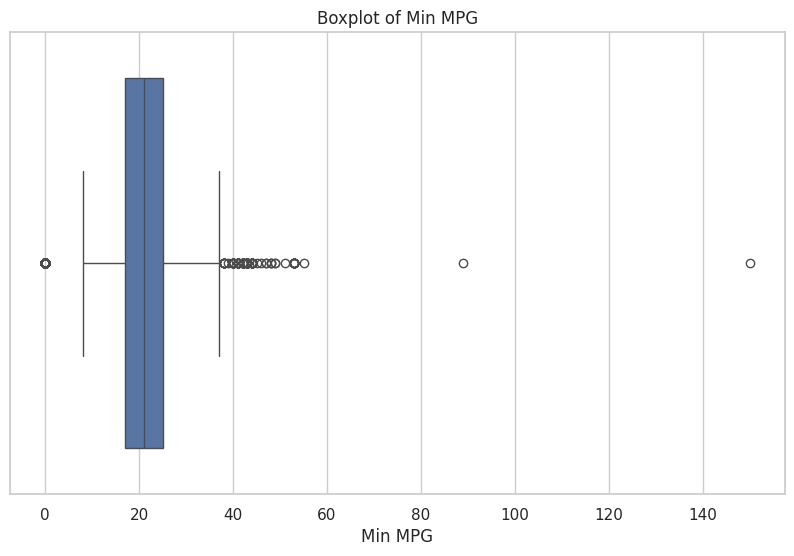

In [ ]:
# Set the style of the visualization
sns.set(style="whitegrid")

# Create a figure for the boxplot
plt.figure(figsize=(10, 6))

# Create a boxplot for Min MPG
sns.boxplot(data=car, x='Min MPG')

# Set the title and labels
plt.title('Boxplot of Min MPG')
plt.xlabel('Min MPG')

# Display the plot
plt.show()

In [ ]:
# Calculate the median for 'Min MPG'
min_mpg_median = car['Min MPG'].median()
min_mpg_median

21.0

In [ ]:
# Verify that there are no missing values left in 'Min MPG'
print(car['Min MPG'].isnull().sum())

1595


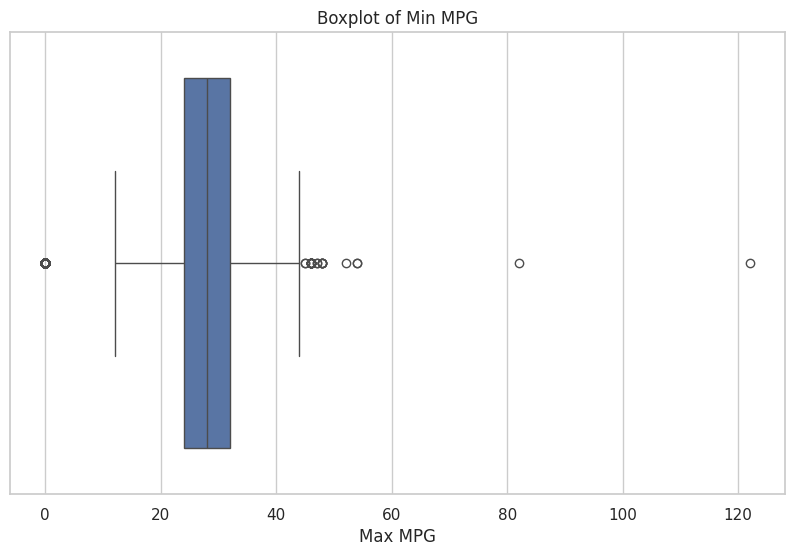

In [ ]:
# Set the style of the visualization
sns.set(style="whitegrid")

# Create a figure for the boxplot
plt.figure(figsize=(10, 6))

# Create a boxplot for Max MPG
sns.boxplot(data=car, x='Max MPG')

# Set the title and labels
plt.title('Boxplot of Min MPG')
plt.xlabel('Max MPG')

# Display the plot
plt.show()

In [ ]:
# Calculate the median for 'Max MPG'
max_mpg_median = car['Max MPG'].median()
max_mpg_median

28.0

In [ ]:
# Fill missing values with median for 'Max MPG'
car['Max MPG'].fillna(max_mpg_median, inplace=True)

<ipython-input-145-1a8a5820b39d>:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  car['Max MPG'].fillna(max_mpg_median, inplace=True)


In [ ]:
# Verify that there are no missing values left in 'Max MPG'
print(car['Max MPG'].isnull().sum())

0


In [ ]:
unique_fueltype = car['Fuel type'].unique()
unique_fueltype

array(['Gasoline ', 'E85 Flex Fuel ', nan, '– ', 'Hybrid ', 'Diesel ',
       'Plug-In Hybrid ', 'Gas/Electric Hyb ', 'Flexible Fuel '],
      dtype=object)

In [ ]:
# Replace 'Unknown' and 'â€“ ' with NaN
car['Fuel type'] = car['Fuel type'].replace(['Unknown', 'â€“ '], np.nan)

In [ ]:
# Replace '-' and 'nan' with 'others' in the 'Fuel type' column
car['Fuel type'] = car['Fuel type'].replace(['-', 'nan',], 'others')

In [ ]:
# Verify that there are no missing values left in 'Fuel type'
print(car['Fuel type'].isnull().sum())

575


In [ ]:
# Checking for missing values in each column
print(car.isnull().sum())

Make                      0
Year                      0
Condition                 0
Mileage                   0
Price                     0
Seller Rating             0
Seller Rating Count       0
Interior color            0
Drivetrain                0
Min MPG                1595
Max MPG                   0
Fuel type               575
Engine Size (L)           0
Accidents or damage    3616
1-owner vehicle           0
Personal use only         0
Clean title            7685
Open recall               0
Comfort_score          4630
Interior_score         4630
Performance_score      4630
Value_score            4630
Exterior_score         4630
Reliability_score      4706
dtype: int64


In [ ]:
car['Accidents or damage'].isnull().sum()

3616

In [ ]:
# Fill missing values with 0
car['Accidents or damage'].fillna(0, inplace=True)

<ipython-input-153-12b27dd6787a>:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  car['Accidents or damage'].fillna(0, inplace=True)


In [ ]:
# Verify that there are no missing values left in 'Accidents or damage'
print(car['Accidents or damage'].isnull().sum())

0


In [ ]:
# Filter data where year is between 2014 and 2024
car= car[(car['Year'] >= 2014) & (car['Year'] < 2024)]
car.head()

,Make,Year,Condition,Mileage,Price,Seller Rating,Seller Rating Count,Interior color,Drivetrain,Min MPG,...,1-owner vehicle,Personal use only,Clean title,Open recall,Comfort_score,Interior_score,Performance_score,Value_score,Exterior_score,Reliability_score
2,McLaren,2016,Used,6305.0,219997.0,3.1,421.0,Carbon Black,RWD,NaN,...,False,False,NaN,0,5.0,5.0,5.0,5.0,5.0,5.0
3,Audi,2016,Used,65715.0,23999.0,3.6,123.0,Black,AWD,23.0,...,False,True,True,0,3.0,5.0,5.0,5.0,5.0,5.0
4,BMW,2018,Used,19830.0,39799.0,4.4,91.0,Black,AWD,0.0,...,True,False,True,0,5.0,5.0,5.0,5.0,5.0,5.0
5,Jeep,2019,Used,52245.0,22966.0,4.2,3030.0,Black,4WD,19.0,...,False,False,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN
6,Cadillac,2019,Used,94008.0,26995.0,4.1,50.0,Black,AWD,18.0,...,False,False,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN


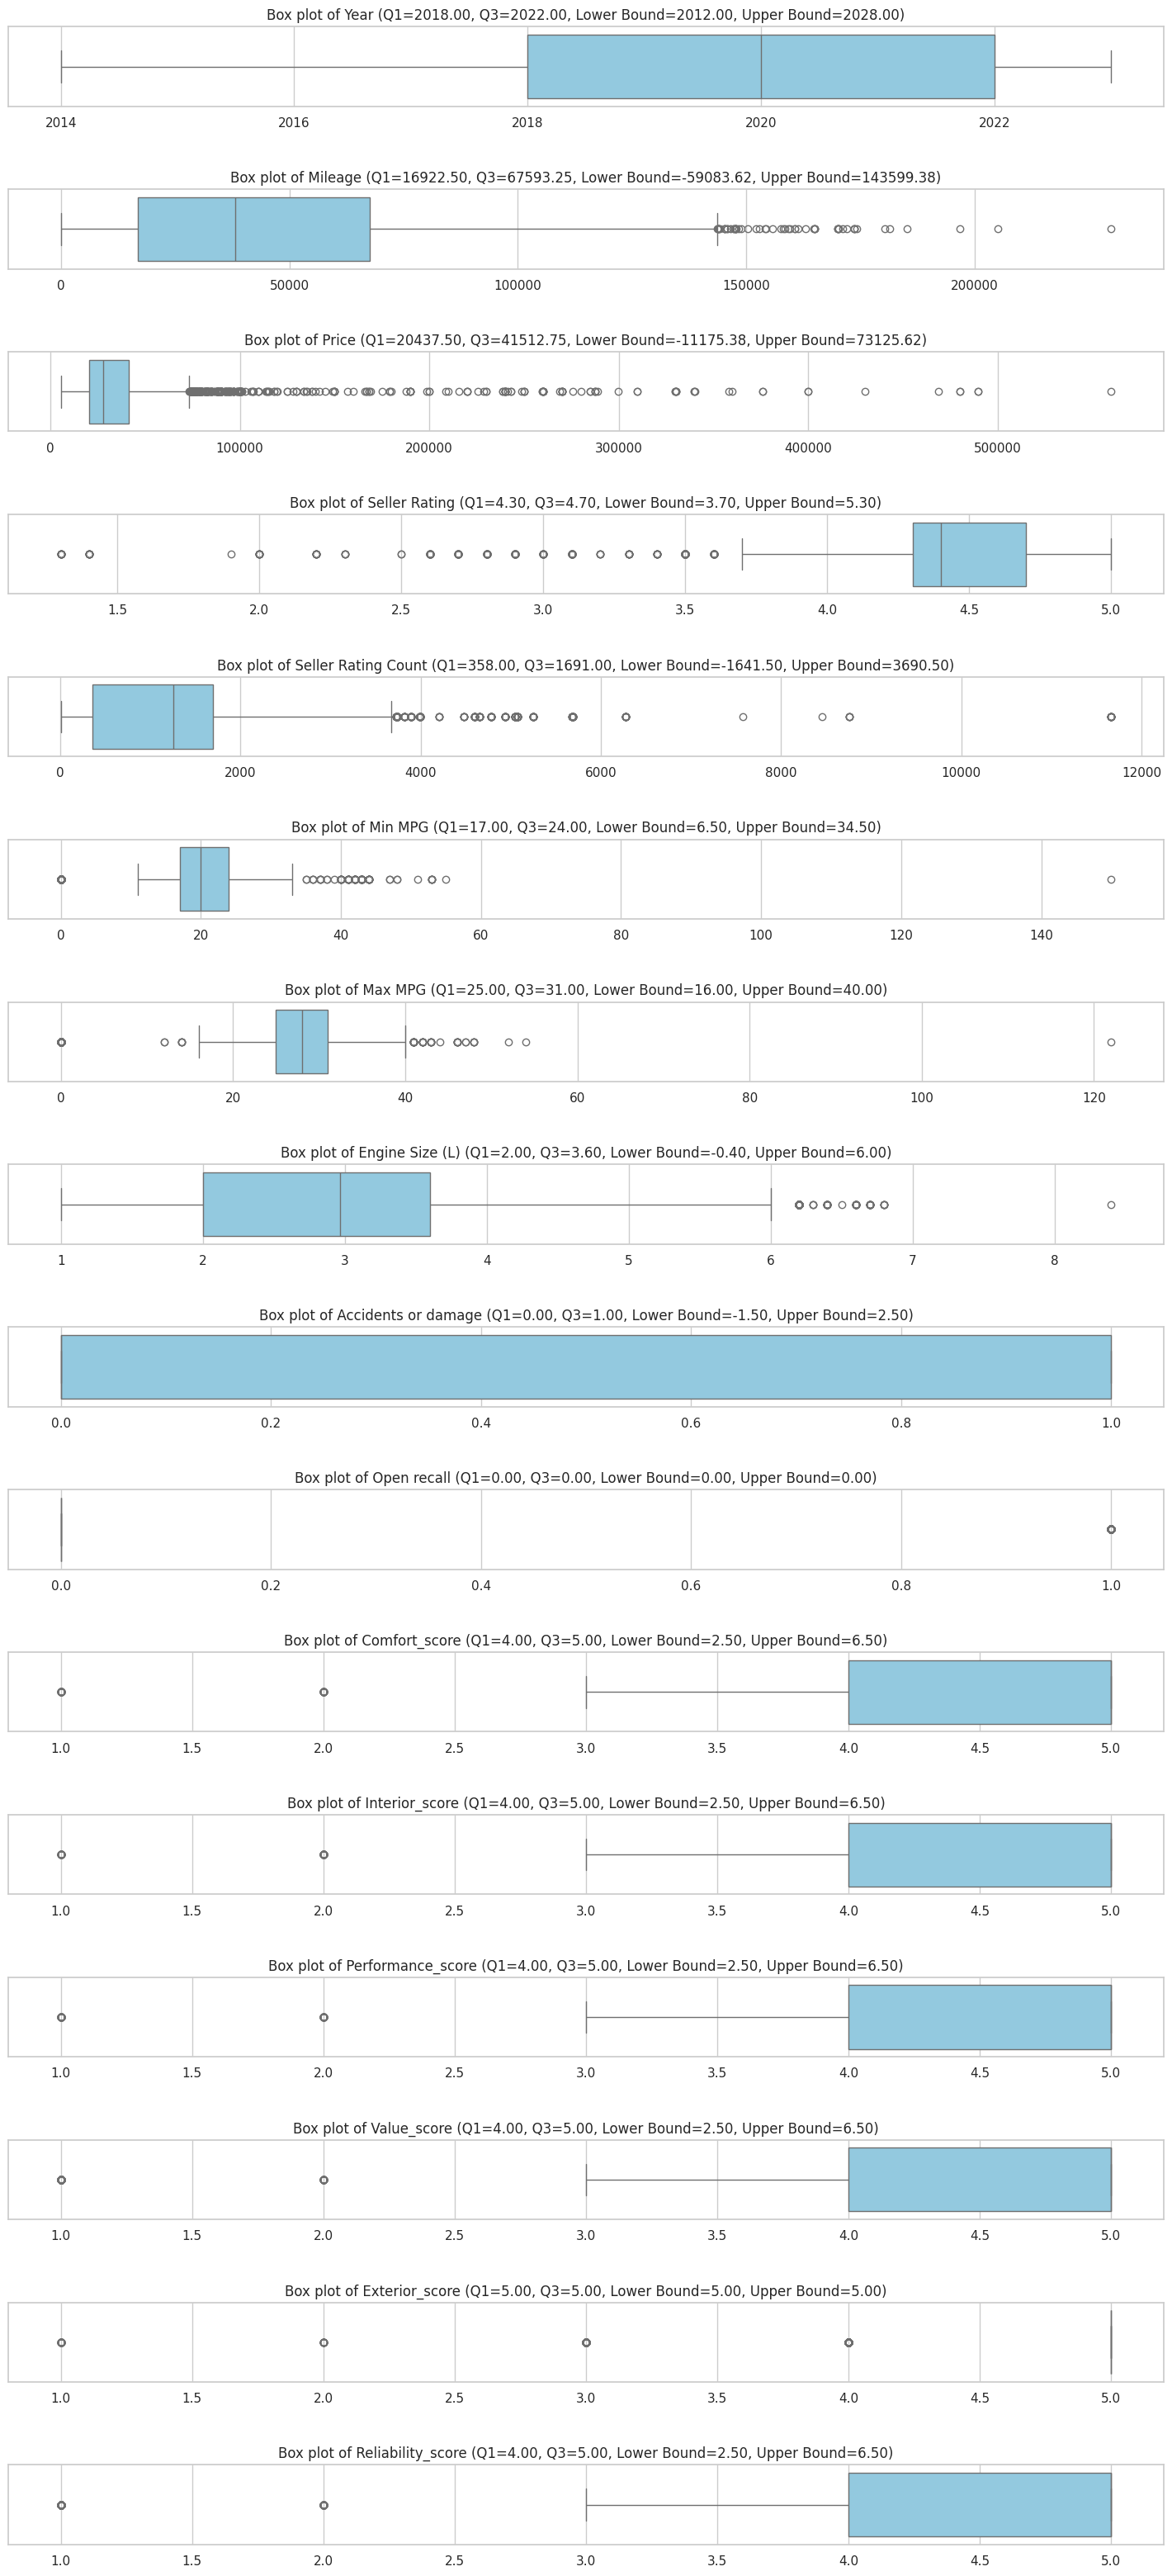

{'Year': 0,
 'Mileage': 57,
 'Price': 308,
 'Seller Rating': 392,
 'Seller Rating Count': 320,
 'Min MPG': 234,
 'Max MPG': 220,
 'Engine Size (L)': 182,
 'Accidents or damage': 0,
 'Open recall': 511,
 'Comfort_score': 95,
 'Interior_score': 99,
 'Performance_score': 114,
 'Value_score': 153,
 'Exterior_score': 452,
 'Reliability_score': 185}

In [ ]:
# Select numerical columns
numerical_columns = car.select_dtypes(include=[np.number]).columns

# Function to detect outliers using IQR
def detect_outliers_iqr(car, column):
    Q1 = car[column].quantile(0.25)
    Q3 = car[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = car[(car[column] < lower_bound) | (car[column] > upper_bound)]
    return outliers, Q1, Q3, lower_bound, upper_bound  # Return Q1, Q3, lower bound, and upper bound along with outliers

# Dictionary to store outliers for each column
outliers_dict = {col: detect_outliers_iqr(car, col) for col in numerical_columns}

# Visualize outliers using box plots
plt.figure(figsize=(15, 2 * len(numerical_columns)))  # Adjust height based on number of plots
for i, col in enumerate(numerical_columns, 1):
    plt.subplot(len(numerical_columns), 1, i)
    outliers, Q1, Q3, lower_bound, upper_bound = outliers_dict[col]
    sns.boxplot(x=car[col], color='skyblue')
    plt.title(f'Box plot of {col} (Q1={Q1:.2f}, Q3={Q3:.2f}, Lower Bound={lower_bound:.2f}, Upper Bound={upper_bound:.2f})', fontsize=12)
    plt.xlabel('')
    plt.tight_layout(pad=3.0)

plt.show()

# Display the count of outliers for each numerical column
outliers_count = {col: len(outliers_dict[col][0]) for col in numerical_columns}
outliers_count

**REMOVE OUTLIER SELLER RATING < 3.7**

In [ ]:

# Function to remove outliers using IQR
def remove_outliers_iqr(car, column):
    Q1 = car[column].quantile(0.25)
    Q3 = car[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    car= car[(car[column] >= lower_bound) & (car[column] <= upper_bound)]
    return car

# Remove outliers for the "Seller Rating" column
car= remove_outliers_iqr(car, 'Seller Rating')

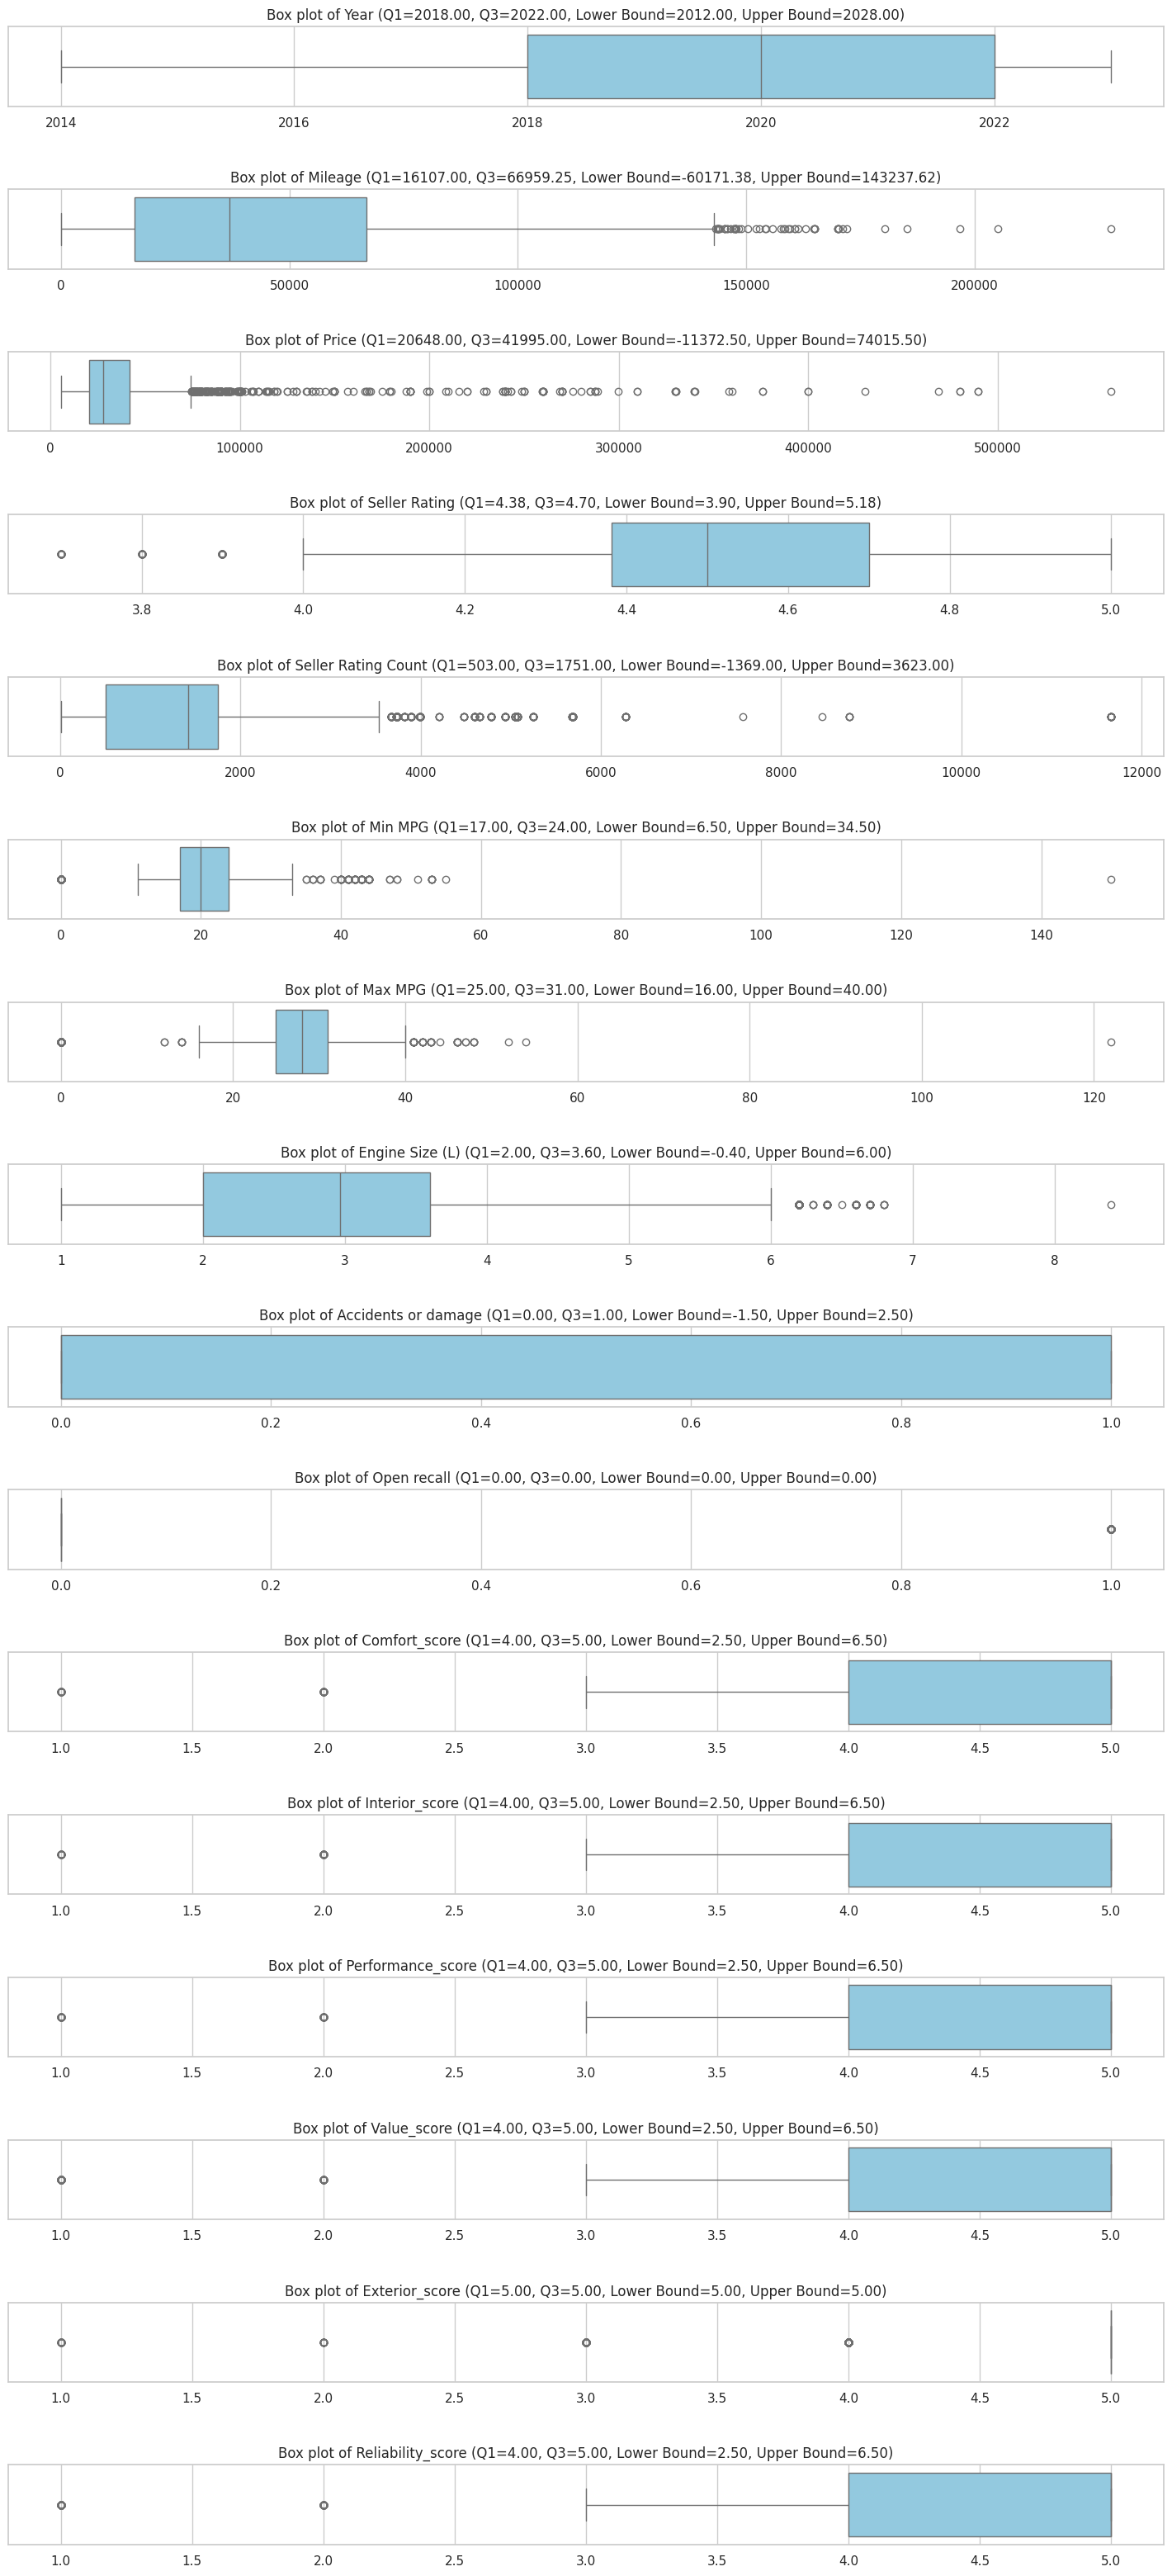

{'Year': 0,
 'Mileage': 54,
 'Price': 277,
 'Seller Rating': 120,
 'Seller Rating Count': 347,
 'Min MPG': 200,
 'Max MPG': 187,
 'Engine Size (L)': 176,
 'Accidents or damage': 0,
 'Open recall': 459,
 'Comfort_score': 83,
 'Interior_score': 85,
 'Performance_score': 98,
 'Value_score': 133,
 'Exterior_score': 404,
 'Reliability_score': 166}

In [ ]:
# Select numerical columns
numerical_columns = car.select_dtypes(include=[np.number]).columns

# Function to detect outliers using IQR
def detect_outliers_iqr(car, column):
    Q1 = car[column].quantile(0.25)
    Q3 = car[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = car[(car[column] < lower_bound) | (car[column] > upper_bound)]
    return outliers, Q1, Q3, lower_bound, upper_bound  # Return Q1, Q3, lower bound, and upper bound along with outliers

# Dictionary to store outliers for each column
outliers_dict = {col: detect_outliers_iqr(car, col) for col in numerical_columns}

# Visualize outliers using box plots
plt.figure(figsize=(15, 2 * len(numerical_columns)))  # Adjust height based on number of plots
for i, col in enumerate(numerical_columns, 1):
    plt.subplot(len(numerical_columns), 1, i)
    outliers, Q1, Q3, lower_bound, upper_bound = outliers_dict[col]
    sns.boxplot(x=car[col], color='skyblue')
    plt.title(f'Box plot of {col} (Q1={Q1:.2f}, Q3={Q3:.2f}, Lower Bound={lower_bound:.2f}, Upper Bound={upper_bound:.2f})', fontsize=12)
    plt.xlabel('')
    plt.tight_layout(pad=3.0)

plt.show()

# Display the count of outliers for each numerical column
outliers_count = {col: len(outliers_dict[col][0]) for col in numerical_columns}
outliers_count

In [ ]:
#Remove column
car = car.drop(['Seller Rating Count','Personal use only','Clean title','Open recall', 'Comfort_score', 'Interior_score', 'Performance_score', 'Value_score', 'Exterior_score', 'Reliability_score'], axis=1)

# Display the updated DataFrame to verify the column removal
car.head()

,Make,Year,Condition,Mileage,Price,Seller Rating,Interior color,Drivetrain,Min MPG,Max MPG,Fuel type,Engine Size (L),Accidents or damage,1-owner vehicle
4,BMW,2018,Used,19830.0,39799.0,4.4,Black,AWD,0.0,0.0,Gasoline,2.0,0.0,True
5,Jeep,2019,Used,52245.0,22966.0,4.2,Black,4WD,19.0,27.0,Gasoline,3.2,1.0,False
6,Cadillac,2019,Used,94008.0,26995.0,4.1,Black,AWD,18.0,27.0,Gasoline,3.6,1.0,False
12,INFINITI,2020,Used,22901.0,38713.0,4.1,Blue,RWD,20.0,27.0,Gasoline,3.0,0.0,True
13,Volkswagen,2014,Used,48650.0,16988.0,4.5,Titan Black,FWD,25.0,33.0,Gasoline,1.8,0.0,True


In [ ]:
print(car)

            Make  Year Condition   Mileage    Price  Seller Rating  \
4            BMW  2018      Used   19830.0  39799.0       4.400000   
5           Jeep  2019      Used   52245.0  22966.0       4.200000   
6       Cadillac  2019      Used   94008.0  26995.0       4.100000   
12      INFINITI  2020      Used   22901.0  38713.0       4.100000   
13    Volkswagen  2014      Used   48650.0  16988.0       4.500000   
...          ...   ...       ...       ...      ...            ...   
8998   Chevrolet  2015      Used  103445.0  10250.0       4.400000   
9006        Jeep  2023       New       5.0  42995.0       4.500000   
9009        Ford  2016      Used  112128.0   7995.0       4.381504   
9010       Tesla  2016      Used   79767.0  30952.0       4.381504   
9012         BMW  2022      Used   48804.0  27979.0       4.800000   

       Interior color Drivetrain  Min MPG  Max MPG       Fuel type  \
4              Black         AWD      0.0      0.0       Gasoline    
5              Blac

In [ ]:
# Recheck again missing value
car.isnull().sum()

,0
Make,0
Year,0
Condition,0
Mileage,0
Price,0
Seller Rating,0
Interior color,0
Drivetrain,0
Min MPG,539
Max MPG,0


In [ ]:
# Handling missing values
# Option 1: Fill missing values with a placeholder or calculated value
car['Min MPG'] = car['Min MPG'].fillna(car['Min MPG'].mean())  # Replace NaN with the mean
car['Fuel type'] = car['Fuel type'].fillna('Unknown')

In [ ]:
# Recheck again missing value
car.isnull().sum()

,0
Make,0
Year,0
Condition,0
Mileage,0
Price,0
Seller Rating,0
Interior color,0
Drivetrain,0
Min MPG,0
Max MPG,0


In [ ]:
# Check for duplicate rows
duplicate_rows = car[car.duplicated()] # Use car.duplicated() instead of car_duplicated()
print(f"Number of duplicate rows: {duplicate_rows.shape[0]}")

Number of duplicate rows: 1131


In [ ]:
# Remove duplicate rows and keep the first occurrence
car= car.drop_duplicates()

In [ ]:
# Check for duplicate rows after removal
print(f"Number of duplicate rows after removal: {car.duplicated().sum()}")

Number of duplicate rows after removal: 0


In [ ]:
output_file = 'car_data.csv'
car.to_csv(output_file, index=False)

## **EXPORT CLEAN DATA TO CSV FILE**

**DATA PREVIEW**

In [ ]:
#Load the data
car_cleaned= pd.read_csv("/content/car_data.csv")

In [ ]:
car_cleaned.head()

,Make,Year,Condition,Mileage,Price,Seller Rating,Interior color,Drivetrain,Min MPG,Max MPG,Fuel type,Engine Size (L),Accidents or damage,1-owner vehicle
0,BMW,2018,Used,19830.0,39799.0,4.4,Black,AWD,0.0,0.0,Gasoline,2.0,0.0,True
1,Jeep,2019,Used,52245.0,22966.0,4.2,Black,4WD,19.0,27.0,Gasoline,3.2,1.0,False
2,Cadillac,2019,Used,94008.0,26995.0,4.1,Black,AWD,18.0,27.0,Gasoline,3.6,1.0,False
3,INFINITI,2020,Used,22901.0,38713.0,4.1,Blue,RWD,20.0,27.0,Gasoline,3.0,0.0,True
4,Volkswagen,2014,Used,48650.0,16988.0,4.5,Titan Black,FWD,25.0,33.0,Gasoline,1.8,0.0,True


In [ ]:
# Checking the number of rows and columns
car_cleaned.shape

(3021, 14)

# **EDA**

In [ ]:
#Load the data
car_cleaned = pd.read_csv('/content/car_data.csv')
car_cleaned

,Make,Year,Condition,Mileage,Price,Seller Rating,Interior color,Drivetrain,Min MPG,Max MPG,Fuel type,Engine Size (L),Accidents or damage,1-owner vehicle
0,BMW,2018,Used,19830.0,39799.0,4.400000,Black,AWD,0.000000,0.0,Gasoline,2.000000,0.0,True
1,Jeep,2019,Used,52245.0,22966.0,4.200000,Black,4WD,19.000000,27.0,Gasoline,3.200000,1.0,False
2,Cadillac,2019,Used,94008.0,26995.0,4.100000,Black,AWD,18.000000,27.0,Gasoline,3.600000,1.0,False
3,INFINITI,2020,Used,22901.0,38713.0,4.100000,Blue,RWD,20.000000,27.0,Gasoline,3.000000,0.0,True
4,Volkswagen,2014,Used,48650.0,16988.0,4.500000,Titan Black,FWD,25.000000,33.0,Gasoline,1.800000,0.0,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3016,Kia,2023,New,15.0,39685.0,4.100000,Black,AWD,22.000000,27.0,Gasoline,2.500000,0.0,others
3017,Tesla,2022,Used,52527.0,22650.0,4.900000,–,RWD,20.599225,28.0,Unknown,2.964659,0.0,True
3018,Jeep,2023,New,23.0,62325.0,4.700000,Global Black,4WD,20.599225,28.0,Hybrid,2.000000,0.0,others
3019,Chevrolet,2019,Used,50383.0,19842.0,4.700000,Jet Black / Dark Titanium,FWD,22.000000,29.0,Gasoline,2.500000,0.0,others


In [ ]:
car_cleaned.head()

,Make,Year,Condition,Mileage,Price,Seller Rating,Interior color,Drivetrain,Min MPG,Max MPG,Fuel type,Engine Size (L),Accidents or damage,1-owner vehicle
0,BMW,2018,Used,19830.0,39799.0,4.4,Black,AWD,0.0,0.0,Gasoline,2.0,0.0,True
1,Jeep,2019,Used,52245.0,22966.0,4.2,Black,4WD,19.0,27.0,Gasoline,3.2,1.0,False
2,Cadillac,2019,Used,94008.0,26995.0,4.1,Black,AWD,18.0,27.0,Gasoline,3.6,1.0,False
3,INFINITI,2020,Used,22901.0,38713.0,4.1,Blue,RWD,20.0,27.0,Gasoline,3.0,0.0,True
4,Volkswagen,2014,Used,48650.0,16988.0,4.5,Titan Black,FWD,25.0,33.0,Gasoline,1.8,0.0,True


In [ ]:
# Recheck again missing value
car_cleaned.isnull().sum()

,0
Make,0
Year,0
Condition,0
Mileage,0
Price,0
Seller Rating,0
Interior color,0
Drivetrain,0
Min MPG,0
Max MPG,0


In [ ]:
from sklearn.preprocessing import StandardScaler

In [ ]:
!pip install ydata-profiling

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 390.9/390.9 kB 8.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.5/296.5 kB 21.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.3/8.3 MB 86.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 686.1/686.1 kB 38.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.8/104.8 kB 8.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 76.0 MB/s eta 0:00:00
  Created wheel for htmlmin: filename=htmlmin-0.1.12-py3-none-any.whl size=27081 sha256=d359e16201dc7db2d3394d32bb77aa1736d4c465bdde857381caa16f2c22ce74
  Stored in directory: /root/.cache/pip/wheels/dd/91/29/a79cecb328d01739e64017b6fb9a1ab9d8cb1853098ec5966d
Successfully built htmlmin
  Attempting uninstall: matplotlib
    Found existing installation: matplotlib 3.10.0
    Uninstalling matplotlib-3.10.0:
      Successfully uninstalled matplotlib-3.10.0


In [ ]:
import ydata_profiling as pp
#Interactive and comprehensive EDA/ data description

# forming ProfileReport and save
# as output.html file
profile = pp.ProfileReport(car_cleaned)
profile

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

# **MODEL**

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, auc, mean_squared_error
from sklearn.neighbors import KNeighborsRegressor # Import KNeighborsRegressor
from sklearn.linear_model import LinearRegression, LogisticRegression # Import LinearRegression
from sklearn.tree import DecisionTreeRegressor # Import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor # Import RandomForestRegressor
import matplotlib.pyplot as plt
import seaborn as sns
from math import sqrt
from sklearn.metrics import r2_score
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.metrics import mean_absolute_error, accuracy_score, classification_report, confusion_matrix, roc_curve, auc, mean_squared_error, precision_score, f1_score


In [ ]:
#Load the data
data_cleaned = pd.read_csv('/content/car_data.csv')
data_cleaned

,Make,Year,Condition,Mileage,Price,Seller Rating,Interior color,Drivetrain,Min MPG,Max MPG,Fuel type,Engine Size (L),Accidents or damage,1-owner vehicle
0,BMW,2018,Used,19830.0,39799.0,4.400000,Black,AWD,0.000000,0.0,Gasoline,2.000000,0.0,True
1,Jeep,2019,Used,52245.0,22966.0,4.200000,Black,4WD,19.000000,27.0,Gasoline,3.200000,1.0,False
2,Cadillac,2019,Used,94008.0,26995.0,4.100000,Black,AWD,18.000000,27.0,Gasoline,3.600000,1.0,False
3,INFINITI,2020,Used,22901.0,38713.0,4.100000,Blue,RWD,20.000000,27.0,Gasoline,3.000000,0.0,True
4,Volkswagen,2014,Used,48650.0,16988.0,4.500000,Titan Black,FWD,25.000000,33.0,Gasoline,1.800000,0.0,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3016,Kia,2023,New,15.0,39685.0,4.100000,Black,AWD,22.000000,27.0,Gasoline,2.500000,0.0,others
3017,Tesla,2022,Used,52527.0,22650.0,4.900000,–,RWD,20.599225,28.0,Unknown,2.964659,0.0,True
3018,Jeep,2023,New,23.0,62325.0,4.700000,Global Black,4WD,20.599225,28.0,Hybrid,2.000000,0.0,others
3019,Chevrolet,2019,Used,50383.0,19842.0,4.700000,Jet Black / Dark Titanium,FWD,22.000000,29.0,Gasoline,2.500000,0.0,others


In [ ]:
# Preprocessing
# Normalize numerical features
numerical_features = ['Mileage', 'Price', 'Seller Rating', 'Min MPG', 'Max MPG', 'Engine Size (L)']
scaler = MinMaxScaler()
data_cleaned[numerical_features] = scaler.fit_transform(data_cleaned[numerical_features])

# Encode categorical features
categorical_features = ['Fuel type', 'Condition', 'Drivetrain']
label_encoders = {}
for feature in categorical_features:
    le = LabelEncoder()
    data_cleaned[feature] = le.fit_transform(data_cleaned[feature])
    label_encoders[feature] = le

In [ ]:
# Define features (X) and target (y)
X = data_cleaned[numerical_features + categorical_features]
y = data_cleaned['Price']

# Split dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [ ]:
# Initialize models
models = {
    'Linear Regression': LinearRegression(),
    'Decision Tree': DecisionTreeRegressor(random_state=42),
    'Random Forest': RandomForestRegressor(random_state=42, n_estimators=100),
    'K-Nearest Neighbors': KNeighborsRegressor(n_neighbors=5)
}

In [ ]:
# Evaluate models
results = {}
plt.figure(figsize=(10, 8))
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    mse = mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    results[name] = {
        'MSE': mse,
        'MAE': mae,
        'R2': r2
    }

<Figure size 1000x800 with 0 Axes>

In [ ]:
# Determine the best model based on R2
best_model = max(results, key=lambda x: results[x]['R2'])

# Output results
print("Model Evaluation Results:")
for name, metrics in results.items():
    print(f"\n{name}:")
    print(f"  MSE: {metrics['MSE']:.4f}")
    print(f"  MAE: {metrics['MAE']:.4f}")
    print(f"  R2: {metrics['R2']:.4f}")

print(f"\nBest Model: {best_model} with R2: {results[best_model]['R2']:.4f}")

Model Evaluation Results:

Linear Regression:
  MSE: 0.0000
  MAE: 0.0000
  R2: 1.0000

Decision Tree:
  MSE: 0.0000
  MAE: 0.0004
  R2: 0.9974

Random Forest:
  MSE: 0.0000
  MAE: 0.0002
  R2: 0.9996

K-Nearest Neighbors:
  MSE: 0.0007
  MAE: 0.0132
  R2: 0.8619

Best Model: Linear Regression with R2: 1.0000



Linear Regression Confusion Matrix:
[[  1   0   0]
 [  0 593   0]
 [  0   0  11]]
Linear Regression Classification Report:
              precision    recall  f1-score   support

         Low       1.00      1.00      1.00         1
      Medium       1.00      1.00      1.00       593
        High       1.00      1.00      1.00        11

    accuracy                           1.00       605
   macro avg       1.00      1.00      1.00       605
weighted avg       1.00      1.00      1.00       605

Linear Regression Accuracy: 1.0000


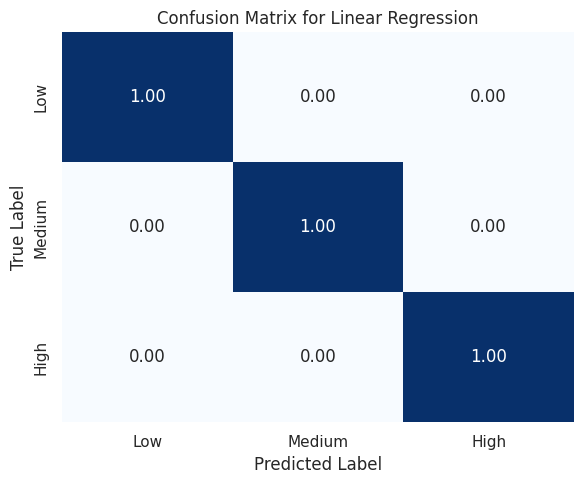


Decision Tree Confusion Matrix:
[[  1   0   0]
 [  0 593   0]
 [  1   0  10]]
Decision Tree Classification Report:
              precision    recall  f1-score   support

         Low       0.50      1.00      0.67         1
      Medium       1.00      1.00      1.00       593
        High       1.00      0.91      0.95        11

    accuracy                           1.00       605
   macro avg       0.83      0.97      0.87       605
weighted avg       1.00      1.00      1.00       605

Decision Tree Accuracy: 0.9983


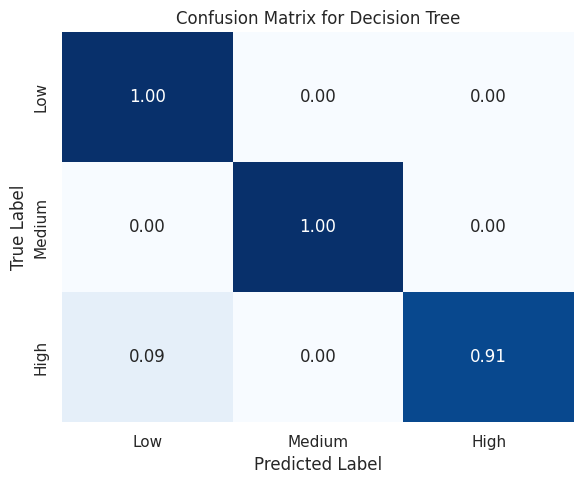


Random Forest Confusion Matrix:
[[  1   0   0]
 [  0 593   0]
 [  1   0  10]]
Random Forest Classification Report:
              precision    recall  f1-score   support

         Low       0.50      1.00      0.67         1
      Medium       1.00      1.00      1.00       593
        High       1.00      0.91      0.95        11

    accuracy                           1.00       605
   macro avg       0.83      0.97      0.87       605
weighted avg       1.00      1.00      1.00       605

Random Forest Accuracy: 0.9983


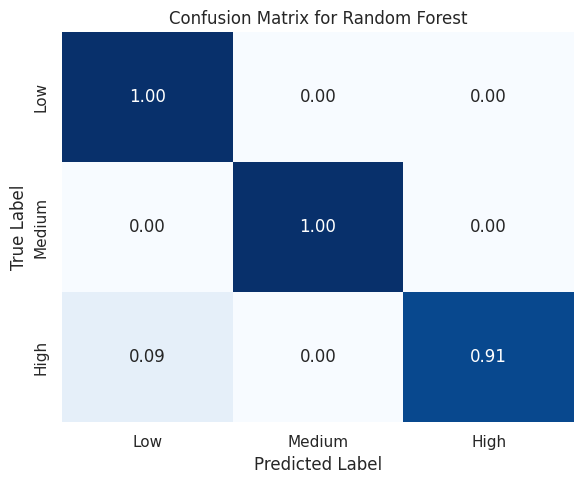


K-Nearest Neighbors Confusion Matrix:
[[  1   0   0]
 [  0 593   0]
 [  0   2   9]]
K-Nearest Neighbors Classification Report:
              precision    recall  f1-score   support

         Low       1.00      1.00      1.00         1
      Medium       1.00      1.00      1.00       593
        High       1.00      0.82      0.90        11

    accuracy                           1.00       605
   macro avg       1.00      0.94      0.97       605
weighted avg       1.00      1.00      1.00       605

K-Nearest Neighbors Accuracy: 0.9967


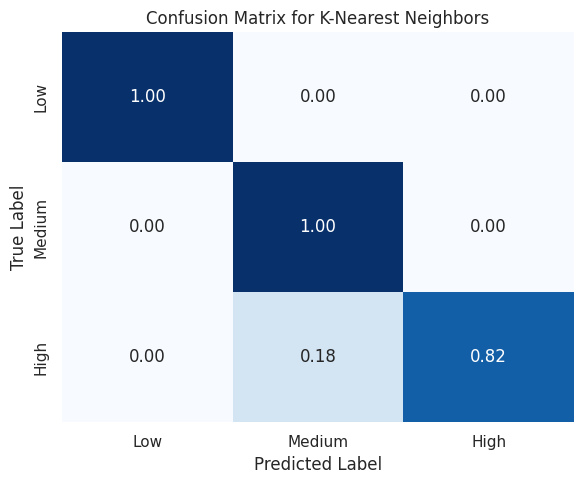

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import numpy as np
import seaborn as sns

# Discretize the target variable "Price" into classes
bins = [0, 0.3, 0.6, 1]
labels = ['Low', 'Medium', 'High']
y_test_class = pd.cut(y_test, bins=[0, 0.3, 0.6, 1], labels=labels)

# Evaluate models and calculate confusion matrix, classification report, and accuracy
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    # Discretize predictions for confusion matrix
    y_pred_class = pd.cut(y_pred, bins=[0, 0.3, 0.6, 1], labels=labels)

    # Calculate accuracy
    accuracy = accuracy_score(y_test_class, y_pred_class)

    # Confusion matrix
    cm = confusion_matrix(y_test_class, y_pred_class)
    print(f"\n{name} Confusion Matrix:")
    print(cm)

    # Classification report
    cr = classification_report(y_test_class, y_pred_class, target_names=labels)
    print(f"{name} Classification Report:")
    print(cr)

    # Print the accuracy
    print(f"{name} Accuracy: {accuracy:.4f}")

    # Normalize the confusion matrix (optional)
    cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

    # Plot the confusion matrix with annotations
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm_normalized, annot=True, fmt=".2f", cmap='Blues', xticklabels=labels, yticklabels=labels, cbar=False)
    plt.title(f"Confusion Matrix for {name}")
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.tight_layout()
    plt.show()


In [ ]:
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Discretize the target variable "y_test" into classes
bins = [0, 0.3, 0.6, 1]
labels = ['Low', 'Medium', 'High']
y_test_class = pd.cut(y_test, bins=bins, labels=labels)

# Initialize a list to store classification report metrics for all models
classification_reports = []

# Evaluate each model in the `models` dictionary
for name, model in models.items():
    # Train the model
    model.fit(X_train, y_train)

    # Predict the output
    y_pred = model.predict(X_test)

    # Discretize predictions for classification comparison
    y_pred_class = pd.cut(y_pred, bins=bins, labels=labels)

    # Calculate accuracy
    accuracy = accuracy_score(y_test_class, y_pred_class)

    # Generate the classification report
    report = classification_report(y_test_class, y_pred_class, output_dict=True, target_names=labels)

    # Append the weighted average metrics and accuracy for comparison
    classification_reports.append({
        'Model': name,
        'Precision': report['weighted avg']['precision'],
        'Recall': report['weighted avg']['recall'],
        'F1-Score': report['weighted avg']['f1-score'],
        'Accuracy': accuracy
    })


# Convert classification reports into a DataFrame
classification_df = pd.DataFrame(classification_reports)

# Sort the DataFrame by F1-Score in descending order
classification_df = classification_df.sort_values(by='F1-Score', ascending=False)

# Display the comparison DataFrame
print("\nModel Comparison Based on Classification Report Metrics:")
print(classification_df)

# Save the comparison DataFrame to a CSV file (Optional)
classification_df.to_csv("model_classification_comparison.csv", index=False)



Model Comparison Based on Classification Report Metrics:
                 Model  Precision    Recall  F1-Score  Accuracy
0    Linear Regression   1.000000  1.000000  1.000000  1.000000
1        Decision Tree   0.999174  0.998347  0.998583  0.998347
2        Random Forest   0.999174  0.998347  0.998583  0.998347
3  K-Nearest Neighbors   0.996705  0.996694  0.996532  0.996694
